# 05 輪廓與連通元件

這個 notebook 記錄如何把 binary mask 轉換成可量測的影像物件。

在傳統影像處理流程中，thresholding 和 morphology 通常會先產生 foreground mask。  
Contours 和 connected components 則把這個 mask 轉成可以量測與判斷的證據。

核心差異是：

- **Mask**：哪些 pixels 屬於前景區域。
- **Boundary**：前景區域外圍的輪廓線。
- **Connected components**：依照 pixel connectivity 分組後的填滿前景區域。
- **Contours**：圍繞前景區域的有順序 boundary paths。

實務問題是：

> 前景被分離出來之後，如何進一步計算、量測、篩選，並轉換成檢測證據？


In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import data
import pandas as pd

OUTPUT_DIR = Path("outputs/05_contours_and_components")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def show_images(images, titles, figsize=(16, 5), cmaps=None, save_path=None):
    cmaps = cmaps or ["gray"] * len(images)
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, len(images), i)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmaps[i-1], vmin=0, vmax=255)
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()

def random_label_color(label_img, seed=42):
    rng = np.random.default_rng(seed)
    labels = np.unique(label_img)
    color = np.zeros((*label_img.shape, 3), dtype=np.uint8)

    for lab in labels:
        if lab == 0:
            continue
        color[label_img == lab] = rng.integers(60, 255, size=3, dtype=np.uint8)

    return color

def add_boxes_and_centroids(gray, stats, centroids, min_area=0, max_area=None):
    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    kept = 0

    for idx in range(1, stats.shape[0]):
        x, y, w, h, area = stats[idx]

        if area < min_area:
            continue

        if max_area is not None and area > max_area:
            continue

        kept += 1
        cx, cy = centroids[idx]
        cv2.rectangle(vis, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.circle(vis, (int(cx), int(cy)), 3, (0, 0, 255), -1)
        cv2.putText(vis, str(kept), (x, max(12, y-4)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 1)

    return vis

def remove_small_components(mask, min_area=400, max_area=None):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = np.zeros_like(mask)

    for idx in range(1, num_labels):
        area = stats[idx, cv2.CC_STAT_AREA]

        if area < min_area:
            continue

        if max_area is not None and area > max_area:
            continue

        cleaned[labels == idx] = 255

    return cleaned

def fill_external_contours(mask, min_area=400, max_area=None):
    """
    Fill each external foreground contour independently.

    This avoids global flood-fill errors where the whole background can be
    accidentally treated as foreground.
    """
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(mask)
    kept = []

    for cnt in contours:
        area = cv2.contourArea(cnt)

        if area < min_area:
            continue

        if max_area is not None and area > max_area:
            continue

        cv2.drawContours(filled, [cnt], -1, 255, thickness=-1)
        kept.append(cnt)

    return filled, kept


## 1. Mask 與 Boundary

**Mask** 通常是一張 binary image。

在 binary mask 中：

```text
white pixels = foreground / object / candidate region
black pixels = background
```

Mask 表示的是一個區域。

**Boundary** 則是這個區域的外圍輪廓線。

最簡單的區分方式是：

```text
mask     = filled region
boundary = outline of the filled region
```

這個差異很重要，因為不同演算法使用的表示方式不同。

Connected component analysis 處理的是填滿的 foreground regions。  
Contour extraction 則是在追蹤這些 regions 的外圍 boundary。

Boundary 可以從 mask 產生，但 boundary 不等於 mask 本身。


## 2. Binary Mask 才是真正的起點

Contours 和 connected components 通常不是直接套用在 raw grayscale image 上。

比較實際的流程是：

```text
grayscale image
→ denoising / enhancement
→ thresholding
→ morphology
→ clean binary mask
→ contours or connected components
→ measurement / filtering / decision
```

Binary mask 是中間最重要的橋樑。

如果 mask 本身有雜訊、破洞、斷裂或錯誤黏在一起，contours 和 connected components 都會繼承這些問題。  
因此，如果一張 mask 只是「勉強可用」，不應該太快把它當作最終量測輸入。

硬幣範例使用 `skimage.data.coins()` 真實影像的下半部 ROI。  
這樣可以聚焦在完整硬幣，避免上方被影像邊界切到的硬幣干擾 component measurement。


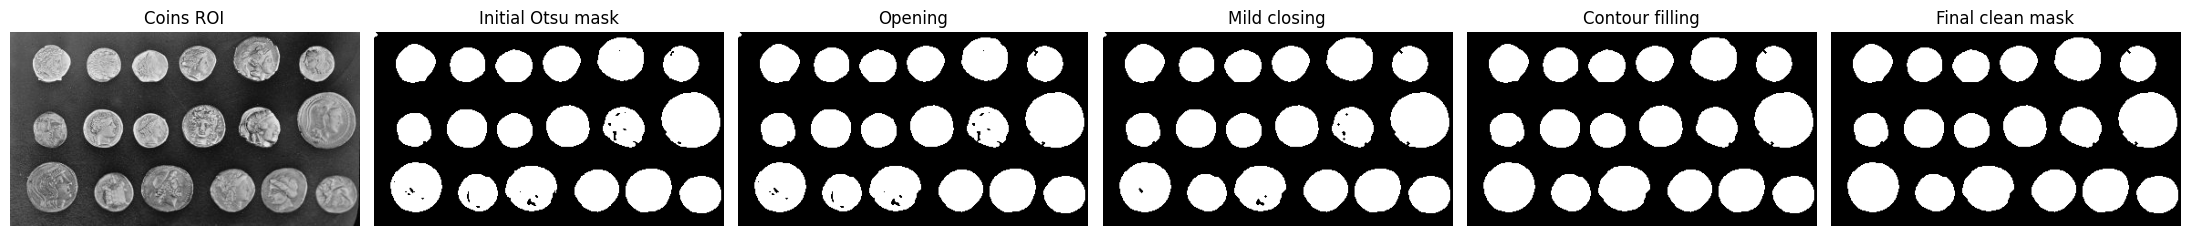

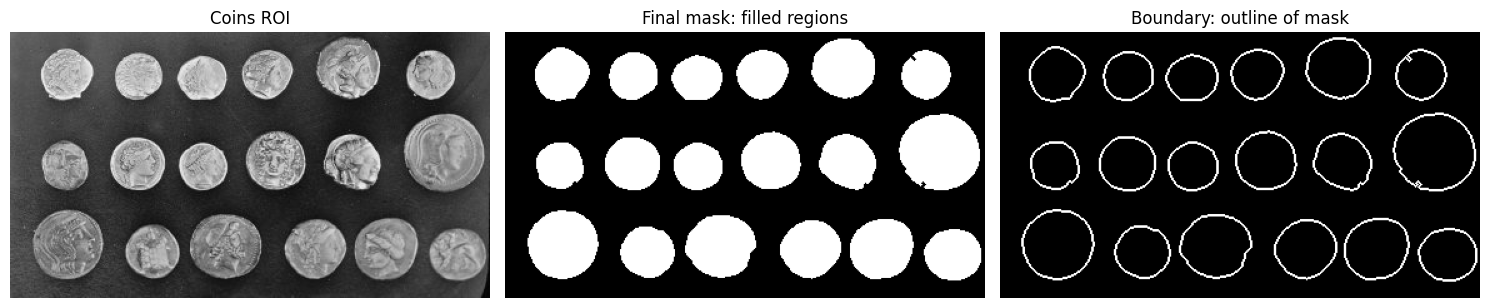

In [18]:
coins_full = data.coins()

# Use a lower ROI from the real coins image.
# This keeps the example focused on full coins and avoids partial top-border coins.
coins = coins_full[90:303, :].copy()

coins_blur = cv2.GaussianBlur(coins, (5, 5), 0)
otsu_val, coins_initial_mask = cv2.threshold(
    coins_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

# Step 1: opening removes tiny foreground dots without merging nearby coins.
mask_open = cv2.morphologyEx(
    coins_initial_mask,
    cv2.MORPH_OPEN,
    kernel_small,
    iterations=1
)

# Step 2: mild closing repairs small breaks while avoiding object merging.
mask_close = cv2.morphologyEx(
    mask_open,
    cv2.MORPH_CLOSE,
    kernel_small,
    iterations=1
)

# Step 3: fill each external coin contour independently.
mask_filled, kept_for_fill = fill_external_contours(
    mask_close,
    min_area=500,
    max_area=6000
)

# Step 4: remove remaining very small or unrealistically large components.
coins_clean_mask = remove_small_components(
    mask_filled,
    min_area=700,
    max_area=6500
)

# Step 5: final mild smoothing.
coins_clean_mask = cv2.morphologyEx(
    coins_clean_mask,
    cv2.MORPH_OPEN,
    kernel_small,
    iterations=1
)

coins_clean_mask = cv2.morphologyEx(
    coins_clean_mask,
    cv2.MORPH_CLOSE,
    kernel_small,
    iterations=1
)

# Boundary extracted from the final clean mask.
mask_boundary = cv2.morphologyEx(
    coins_clean_mask,
    cv2.MORPH_GRADIENT,
    kernel_small
)

cv2.imwrite(str(OUTPUT_DIR / "01_coins_roi_original.png"), coins)
cv2.imwrite(str(OUTPUT_DIR / "02_coins_initial_otsu_mask.png"), coins_initial_mask)
cv2.imwrite(str(OUTPUT_DIR / "03_coins_mask_after_opening.png"), mask_open)
cv2.imwrite(str(OUTPUT_DIR / "04_coins_mask_after_mild_closing.png"), mask_close)
cv2.imwrite(str(OUTPUT_DIR / "05_coins_mask_after_contour_filling.png"), mask_filled)
cv2.imwrite(str(OUTPUT_DIR / "06_coins_final_clean_mask.png"), coins_clean_mask)
cv2.imwrite(str(OUTPUT_DIR / "07_coins_boundary_from_clean_mask.png"), mask_boundary)

show_images(
    [coins, coins_initial_mask, mask_open, mask_close, mask_filled, coins_clean_mask],
    ["Coins ROI", "Initial Otsu mask", "Opening", "Mild closing", "Contour filling", "Final clean mask"],
    figsize=(22, 5),
    save_path=OUTPUT_DIR / "01_mask_cleaning_progression.png"
)

show_images(
    [coins, coins_clean_mask, mask_boundary],
    ["Coins ROI", "Final mask: filled regions", "Boundary: outline of mask"],
    figsize=(15, 5),
    save_path=OUTPUT_DIR / "02_mask_vs_boundary.png"
)


### 工程筆記

初始 Otsu mask 已經能分離出硬幣區域，但部分硬幣內部仍有黑洞或小型邊界缺陷。

這個清理流程中，每一步有不同目的：

- **Opening**：移除小型孤立白色雜訊。
- **Mild closing**：修補小斷裂，同時避免把相鄰硬幣黏在一起。
- **Contour filling**：逐一填滿外部硬幣輪廓，避免 global flood-fill 造成整張背景被誤填。
- **Small-component removal**：移除太小或太大的 foreground regions。
- **Final smoothing**：讓 mask boundary 稍微不那麼鋸齒。

這不代表 mask 已經是完美語意分割。  
它代表這張 mask 比較適合作為量測輸入。

核心實務觀念是：

> 粗略 mask 可以保留下來做比較，但後續量測應該使用更乾淨的 mask。


## 3. Connected Component Analysis

Connected component analysis 會把相鄰的 foreground pixels 分成不同 labeled regions。

簡單來說：

> 只要白色 pixels 彼此相連，它們就屬於同一個 component。

它的輸出不只是視覺邊界。  
它可以直接提供 region-level statistics：

- label id
- area
- bounding box
- centroid
- width and height

這讓 connected components 很適合用在檢測任務，例如計算物件數量、過濾小雜訊、尋找候選瑕疵，或量測分離區域。


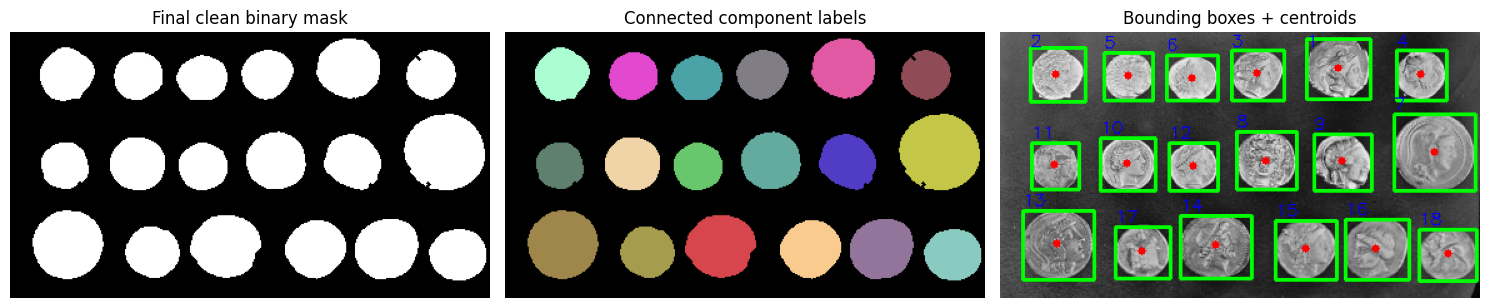

,label,x,y,width,height,area_pixels,centroid_x,centroid_y
6,7,315,66,65,61,3084,347.51,96.12
12,13,18,143,57,55,2423,45.93,169.82
13,14,144,147,57,50,2158,172.15,170.92
15,16,276,150,51,48,1949,300.93,173.17
0,1,245,6,51,48,1907,270.71,29.12
7,8,189,80,48,46,1728,212.42,103.15
14,15,220,151,49,47,1719,244.18,173.29
8,9,251,82,46,45,1525,273.94,103.73
9,10,80,85,44,42,1501,101.68,105.45
17,18,335,158,46,41,1492,358.13,178.00


In [19]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    coins_clean_mask,
    connectivity=8
)

label_color = random_label_color(labels)
boxes_vis = add_boxes_and_centroids(coins, stats, centroids, min_area=700, max_area=6500)

cv2.imwrite(str(OUTPUT_DIR / "08_connected_components_labels.png"), label_color)
cv2.imwrite(str(OUTPUT_DIR / "09_connected_components_boxes.png"), boxes_vis)

show_images(
    [coins_clean_mask, label_color, boxes_vis],
    ["Final clean binary mask", "Connected component labels", "Bounding boxes + centroids"],
    figsize=(15, 5),
    save_path=OUTPUT_DIR / "03_connected_components_result.png"
)

rows = []
for idx in range(1, stats.shape[0]):
    x, y, w, h, area = stats[idx]
    cx, cy = centroids[idx]

    if area < 700 or area > 6500:
        continue

    rows.append({
        "label": len(rows) + 1,
        "x": int(x),
        "y": int(y),
        "width": int(w),
        "height": int(h),
        "area_pixels": int(area),
        "centroid_x": round(float(cx), 2),
        "centroid_y": round(float(cy), 2),
    })

df_components = pd.DataFrame(rows).sort_values("area_pixels", ascending=False)
df_components.to_csv(OUTPUT_DIR / "10_connected_components_stats.csv", index=False)
df_components.head(10)


### 工程筆記

Connected components 偏向 region-oriented。

它適合回答這類問題：

- 有多少個 foreground regions？
- 每個 region 在哪裡？
- 每個 region 多大？
- 哪些 regions 太小，應該視為雜訊移除？
- 每個 candidate object 的 centroid 在哪裡？

關鍵限制是 connected components 只看 pixel connectivity，不理解物件身份。

如果兩個物件在 binary mask 中碰在一起，它們就會變成同一個 component。  
如果一個物件在 mask 中斷成數塊，它就會變成多個 components。

這也是為什麼量測前的 mask cleanup 很重要。


## 4. Contour Extraction

Contours 描述的是物件邊界。

內化理解是：

> Contour 是沿著 foreground region 外圍走出來的一條有順序 boundary path。

當邊界本身很重要時，contours 特別有用：

- perimeter
- shape
- contour area
- polygon approximation
- convex hull
- hierarchy
- boundary-based filtering

這和 connected components 不同。

Connected components 描述填滿的區域。  
Contours 描述圍繞那些區域的邊界曲線。


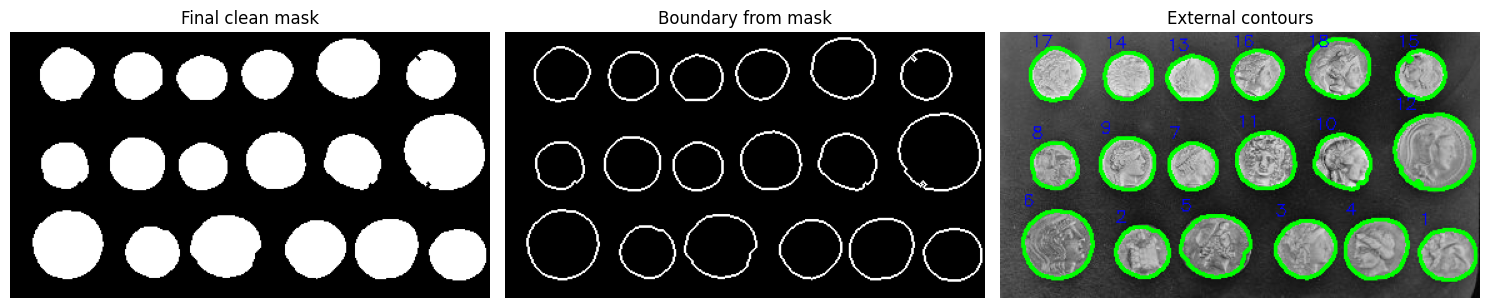

,contour_id,x,y,width,height,contour_area,perimeter,circularity
0,1,335,158,46,41,1430.0,141.88,0.893
1,2,92,156,44,41,1326.5,137.30,0.884
2,3,220,151,49,47,1654.0,152.85,0.890
3,4,276,150,51,48,1877.5,162.95,0.889
4,5,144,147,57,50,2083.5,173.10,0.874
5,6,18,143,57,55,2344.0,182.51,0.884
6,7,135,89,39,38,1116.5,125.98,0.884
7,8,25,89,38,37,1060.5,123.98,0.867
8,9,80,85,44,42,1439.0,141.05,0.909
9,10,251,82,46,45,1461.0,148.37,0.834


In [20]:
contours_external, hierarchy_external = cv2.findContours(
    coins_clean_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

contour_vis = cv2.cvtColor(coins, cv2.COLOR_GRAY2BGR)
filtered_contours = []
contour_rows = []

for cnt in contours_external:
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, closed=True)

    if area < 700 or area > 6500:
        continue

    x, y, w, h = cv2.boundingRect(cnt)
    filtered_contours.append(cnt)

    contour_rows.append({
        "contour_id": len(filtered_contours),
        "x": int(x),
        "y": int(y),
        "width": int(w),
        "height": int(h),
        "contour_area": round(float(area), 2),
        "perimeter": round(float(perimeter), 2),
        "circularity": round(float(4*np.pi*area/(perimeter**2)) if perimeter > 0 else 0, 3),
    })

cv2.drawContours(contour_vis, filtered_contours, -1, (0, 255, 0), 2)

for row in contour_rows:
    cv2.putText(contour_vis, str(row["contour_id"]),
                (row["x"], max(12, row["y"]-4)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 1)

cv2.imwrite(str(OUTPUT_DIR / "11_external_contours_from_clean_mask.png"), contour_vis)

df_contours = pd.DataFrame(contour_rows)
df_contours.to_csv(OUTPUT_DIR / "12_contour_measurements.csv", index=False)

show_images(
    [coins_clean_mask, mask_boundary, contour_vis],
    ["Final clean mask", "Boundary from mask", "External contours"],
    figsize=(15, 5),
    save_path=OUTPUT_DIR / "04_external_contours_result.png"
)

df_contours.head(10)


### 工程筆記

Contours 偏向 boundary-oriented。

當後續判斷依賴形狀，而不只是面積時，contours 會更有用。

例如：

- 量測 perimeter
- 檢查邊界是否平滑或不規則
- 將形狀近似成 polygon
- 偵測零件是否有孔洞
- 只取外部物件輪廓
- 根據 circularity 或 aspect ratio 篩選

Contours 也更依賴邊界品質。  
如果 mask boundary 很鋸齒、斷裂或充滿雜訊，contour measurements 也會不穩定。


## 5. Contours vs. Connected Components

Contours 和 connected components 在簡單情況下看起來很像，但它們不是同一種表示法。

可以這樣區分：

```text
Connected components:
    "哪些 pixels 屬於同一個填滿的前景區域？"

Contours:
    "圍繞這個區域的邊界路徑是什麼？"
```

當 foreground object 內部有洞時，差異會更明顯。

Connected components 會標記前景區域。  
Contour hierarchy 則可以描述外部邊界與內部孔洞之間的關係。


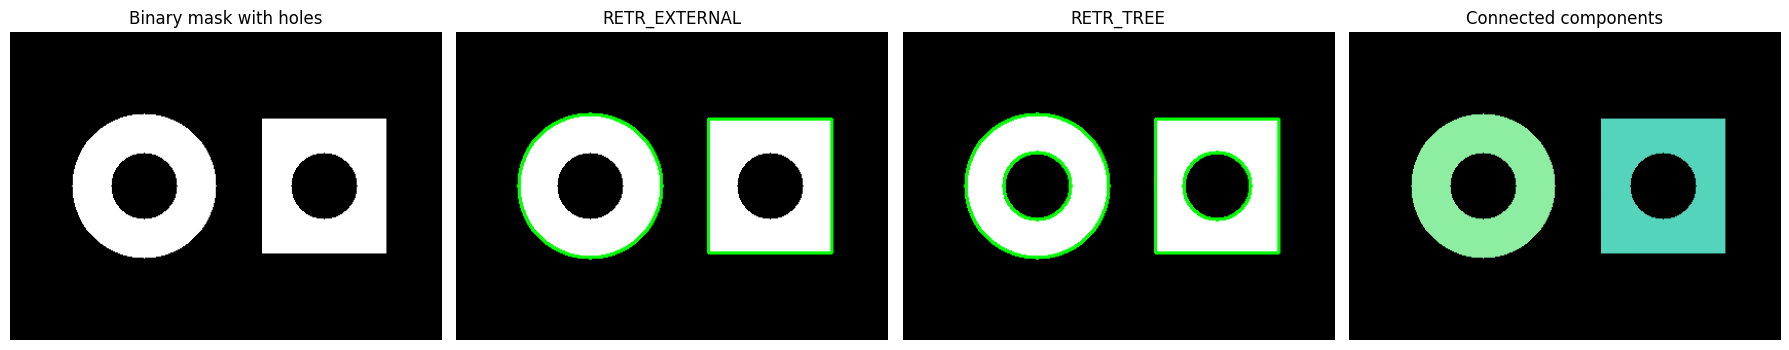

Number of external contours: 2
Number of tree contours: 4
Connected components including background: 3
Hierarchy array:
[[[ 2 -1  1 -1]
  [-1 -1 -1  0]
  [-1  0  3 -1]
  [-1 -1 -1  2]]]


In [21]:
ring = np.zeros((300, 420), dtype=np.uint8)

cv2.circle(ring, (130, 150), 70, 255, -1)
cv2.circle(ring, (130, 150), 32, 0, -1)

cv2.rectangle(ring, (245, 85), (365, 215), 255, -1)
cv2.circle(ring, (305, 150), 32, 0, -1)

contours_ext, _ = cv2.findContours(
    ring,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

contours_tree, hierarchy_tree = cv2.findContours(
    ring,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_SIMPLE
)

ring_ext = cv2.cvtColor(ring, cv2.COLOR_GRAY2BGR)
ring_tree = cv2.cvtColor(ring, cv2.COLOR_GRAY2BGR)

cv2.drawContours(ring_ext, contours_ext, -1, (0, 255, 0), 2)
cv2.drawContours(ring_tree, contours_tree, -1, (0, 255, 0), 2)

num_ring, ring_labels, ring_stats, ring_centroids = cv2.connectedComponentsWithStats(
    ring,
    connectivity=8
)

ring_label_color = random_label_color(ring_labels, seed=9)

cv2.imwrite(str(OUTPUT_DIR / "13_ring_mask_with_holes.png"), ring)
cv2.imwrite(str(OUTPUT_DIR / "14_ring_external_contours.png"), ring_ext)
cv2.imwrite(str(OUTPUT_DIR / "15_ring_tree_contours.png"), ring_tree)
cv2.imwrite(str(OUTPUT_DIR / "16_ring_components.png"), ring_label_color)

show_images(
    [ring, ring_ext, ring_tree, ring_label_color],
    ["Binary mask with holes", "RETR_EXTERNAL", "RETR_TREE", "Connected components"],
    figsize=(18, 5),
    save_path=OUTPUT_DIR / "05_contour_hierarchy_vs_components.png"
)

print("Number of external contours:", len(contours_ext))
print("Number of tree contours:", len(contours_tree))
print("Connected components including background:", num_ring)
print("Hierarchy array:")
print(hierarchy_tree)


### 觀察

`RETR_EXTERNAL` 只保留最外層邊界。

`RETR_TREE` 會保留外部輪廓和內部孔洞之間的階層關係。

Connected components 會標記 foreground regions，但不會用同樣方式直接描述內部邊界 hierarchy。

這就是為什麼 contour retrieval mode 很重要。

如果檢測任務只關心外部物件邊界，`RETR_EXTERNAL` 可能就足夠。  
如果孔洞、內部瑕疵或 nested regions 很重要，就需要考慮 hierarchy-aware contour retrieval。


## 6. Contour Approximation

一條 contour 可能包含很多 points。

`CHAIN_APPROX_NONE` 會保留所有 boundary points。  
`CHAIN_APPROX_SIMPLE` 會移除直線段上的冗餘 points。

核心概念是：

> Contour approximation 會把邊界細節簡化成比較簡潔的幾何描述。

當不需要每個邊界 pixel，但需要整體形狀時，這會很有用。


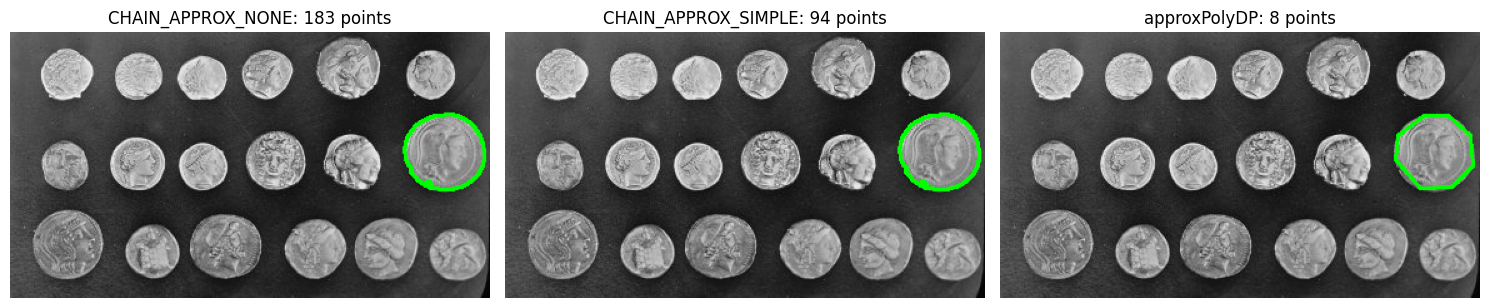

In [22]:
contours_none, _ = cv2.findContours(
    coins_clean_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

contours_simple, _ = cv2.findContours(
    coins_clean_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

largest_none = max(contours_none, key=cv2.contourArea)
largest_simple = max(contours_simple, key=cv2.contourArea)

epsilon = 0.02 * cv2.arcLength(largest_simple, True)
approx = cv2.approxPolyDP(largest_simple, epsilon, True)

contour_none_img = cv2.cvtColor(coins, cv2.COLOR_GRAY2BGR)
contour_simple_img = cv2.cvtColor(coins, cv2.COLOR_GRAY2BGR)
approx_img = cv2.cvtColor(coins, cv2.COLOR_GRAY2BGR)

cv2.drawContours(contour_none_img, [largest_none], -1, (0, 255, 0), 2)
cv2.drawContours(contour_simple_img, [largest_simple], -1, (0, 255, 0), 2)
cv2.drawContours(approx_img, [approx], -1, (0, 255, 0), 2)

cv2.imwrite(str(OUTPUT_DIR / "17_chain_approx_none.png"), contour_none_img)
cv2.imwrite(str(OUTPUT_DIR / "18_chain_approx_simple.png"), contour_simple_img)
cv2.imwrite(str(OUTPUT_DIR / "19_poly_approx.png"), approx_img)

show_images(
    [contour_none_img, contour_simple_img, approx_img],
    [
        f"CHAIN_APPROX_NONE: {len(largest_none)} points",
        f"CHAIN_APPROX_SIMPLE: {len(largest_simple)} points",
        f"approxPolyDP: {len(approx)} points"
    ],
    figsize=(15, 5),
    save_path=OUTPUT_DIR / "06_contour_approximation_comparison.png"
)


### 工程筆記

Approximation 是一種取捨。

保留所有 points 可以保留邊界細節，但資料量較大。  
簡化 contour 可以讓 shape analysis 更穩定，但可能移除小型邊界異常。

這在檢測中很重要：

- 如果任務是偵測小缺角或鋸齒狀瑕疵，過度 approximation 可能會把瑕疵隱藏。
- 如果任務是辨識大型幾何形狀，approximation 可以讓判斷更穩定。


## 7. 使用量測特徵進行 Shape Filtering

Contours 被抽出後，可以轉換成數值特徵。

常見特徵包含：

- area
- perimeter
- bounding box
- aspect ratio
- circularity
- approximated vertices 數量

Circularity 的簡單公式是：

```text
circularity = 4π × area / perimeter²
```

越接近正圓，數值越接近 1。  
越不規則或越狹長，circularity 通常越低。

這不是 deep-learning classifier。  
這是一種 rule-based measurement pipeline。


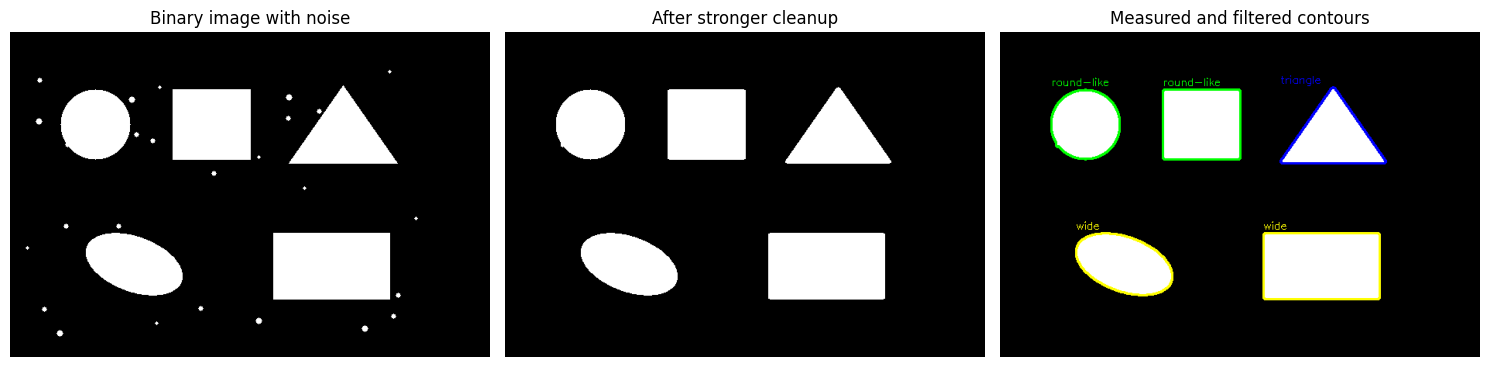

,shape_id,area,perimeter,circularity,aspect_ratio,approx_vertices,label
0,1,12744.0,467.66,0.732,1.756,4,wide
1,2,7150.0,340.05,0.777,1.543,8,wide
2,3,8994.0,377.66,0.792,1.110,4,round-like
3,4,6239.5,297.66,0.885,0.978,8,round-like
4,5,6986.0,388.33,0.582,1.384,3,triangle


In [23]:
shape_img = np.zeros((420, 620), dtype=np.uint8)

cv2.circle(shape_img, (110, 120), 45, 255, -1)
cv2.rectangle(shape_img, (210, 75), (310, 165), 255, -1)

triangle = np.array([[430, 70], [500, 170], [360, 170]], np.int32)
cv2.fillPoly(shape_img, [triangle], 255)

cv2.ellipse(shape_img, (160, 300), (65, 35), 20, 0, 360, 255, -1)
cv2.rectangle(shape_img, (340, 260), (490, 345), 255, -1)

rng = np.random.default_rng(3)
for _ in range(30):
    x = int(rng.integers(20, 600))
    y = int(rng.integers(20, 400))
    r = int(rng.integers(2, 5))
    cv2.circle(shape_img, (x, y), r, 255, -1)

shape_clean = cv2.morphologyEx(
    shape_img,
    cv2.MORPH_OPEN,
    cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
)

shape_clean = remove_small_components(shape_clean, min_area=200)

shape_contours, _ = cv2.findContours(
    shape_clean,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

shape_vis = cv2.cvtColor(shape_clean, cv2.COLOR_GRAY2BGR)
shape_rows = []

for cnt in shape_contours:
    area = cv2.contourArea(cnt)

    if area < 200:
        continue

    perimeter = cv2.arcLength(cnt, True)
    x, y, w, h = cv2.boundingRect(cnt)
    circularity = 4 * np.pi * area / (perimeter ** 2) if perimeter > 0 else 0
    aspect_ratio = w / h if h > 0 else 0
    approx_s = cv2.approxPolyDP(cnt, 0.03 * perimeter, True)

    if circularity > 0.78:
        label = "round-like"
        color = (0, 255, 0)
    elif len(approx_s) == 3:
        label = "triangle"
        color = (255, 0, 0)
    elif aspect_ratio > 1.4:
        label = "wide"
        color = (0, 255, 255)
    else:
        label = "box-like"
        color = (0, 128, 255)

    cv2.drawContours(shape_vis, [cnt], -1, color, 2)
    cv2.putText(shape_vis, label, (x, max(14, y-5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    shape_rows.append({
        "shape_id": len(shape_rows) + 1,
        "area": round(float(area), 2),
        "perimeter": round(float(perimeter), 2),
        "circularity": round(float(circularity), 3),
        "aspect_ratio": round(float(aspect_ratio), 3),
        "approx_vertices": int(len(approx_s)),
        "label": label
    })

df_shapes = pd.DataFrame(shape_rows)
df_shapes.to_csv(OUTPUT_DIR / "21_shape_filtering_measurements.csv", index=False)

cv2.imwrite(str(OUTPUT_DIR / "20_shape_filtering_result.png"), shape_vis)

show_images(
    [shape_img, shape_clean, shape_vis],
    ["Binary image with noise", "After stronger cleanup", "Measured and filtered contours"],
    figsize=(15, 5),
    save_path=OUTPUT_DIR / "07_shape_filtering_pipeline.png"
)

df_shapes


### 工程筆記

這個例子展示 contour features 如何變成 decision rules。

方法很簡單，但流程是有意義的：

```text
binary mask
→ morphology cleanup
→ contour extraction
→ feature measurement
→ rule-based filtering
```

這接近許多傳統檢測系統的工作方式。

重要限制是，這些規則依賴影像條件與物件一致性。  
如果光照、尺度、視角或物件形狀變化太大，固定規則可能會變得不穩定。


## 8. 最終總結

Contours 和 connected components 都用在 binary segmentation 之後，但兩者不能完全互換。

| Method | Representation | Good For | Main Limitation |
|---|---|---|---|
| Connected components | Filled foreground regions | Counting, area, bounding box, centroid | Touching objects merge; broken objects split |
| Contours | Boundary paths | Shape, perimeter, hierarchy, approximation | Sensitive to boundary noise and broken masks |

實務心法是：

> Binary segmentation 產生 candidate regions。  
> Components 和 contours 把這些 regions 轉換成可量測證據。

一個完整的檢測式流程通常會像這樣：

```text
image acquisition
→ preprocessing
→ thresholding / edge detection
→ morphology
→ clean mask
→ components or contours
→ measurement
→ filtering
→ OK / NG decision
```

關鍵細節是：measurement 的可靠程度，會受到 mask 品質限制。


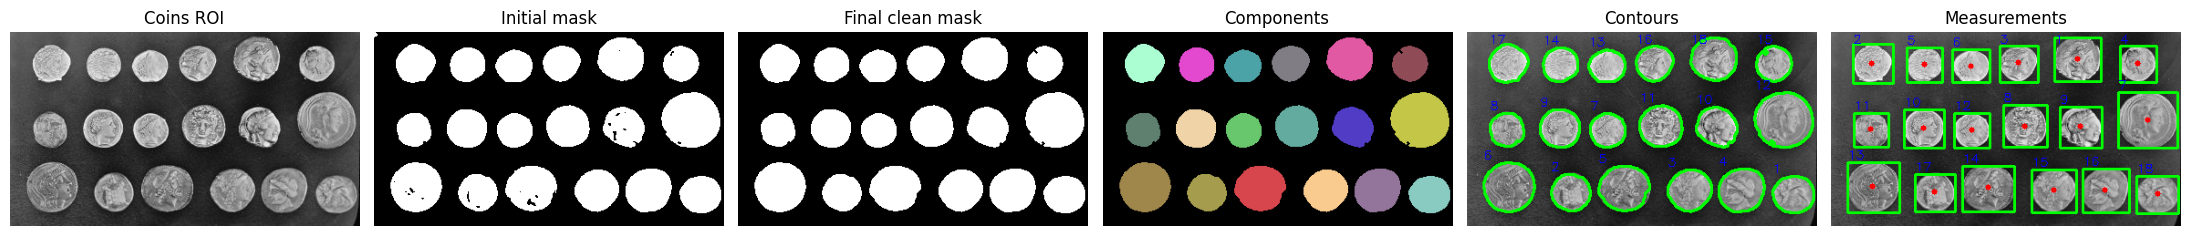

In [24]:
show_images(
    [coins, coins_initial_mask, coins_clean_mask, label_color, contour_vis, boxes_vis],
    ["Coins ROI", "Initial mask", "Final clean mask", "Components", "Contours", "Measurements"],
    figsize=(22, 5),
    save_path=OUTPUT_DIR / "08_pipeline_summary.png"
)
